In [110]:
import os
import cv2
import numpy as np
from tqdm import tqdm
import pandas as pd
import torch
import matplotlib.pyplot as plt
from IPython.display import Image, display
from dotenv import find_dotenv, load_dotenv


In [111]:
#load in the train data - explore and clean

#find the environment file
env_file = find_dotenv()
load_dotenv()

#path to train images
path = os.getenv("DR_IMAGES_PATH")
#path to csv file containing img id code and grading
label_csv = os.getenv("DR_LABELS_CSV")


if not os.path.isfile(label_csv):
    print(f"File not found")
else:
    pass
    

try:
    with open (label_csv, "r") as f:
     #our csv file
     df = pd.read_csv(label_csv)
except Exception as e:
   raise FileNotFoundError("this file does not exist", e)   

  

id_code, diagnosis= df["id_code"][0], df["diagnosis"][0]

print("id_code:", id_code , ": diagnosis:" ,diagnosis)

print("------------------------------------------------")

#print the first 5 labels
print(df.head())
#print the last 5 labels
print(df.tail())




id_code: 000c1434d8d7 : diagnosis: 2
------------------------------------------------
        id_code  diagnosis
0  000c1434d8d7          2
1  001639a390f0          4
2  0024cdab0c1e          1
3  002c21358ce6          0
4  005b95c28852          0
           id_code  diagnosis
3657  ffa47f6a7bf4          2
3658  ffc04fed30e6          0
3659  ffcf7b45f213          2
3660  ffd97f8cd5aa          0
3661  ffec9a18a3ce          2


In [112]:
#load in the train data - explore and clean
training_images=[]
missing_labels=[]
#count the sample distribution per class 
count={"No DR" :0 , "Mild DR": 0, "Moderate DR": 0, "Severe DR": 0, "Proliferative DR" : 0}
IMG_SIZE = 224



#iterate through the data in subsets, iterating through x images at a time
#for chunk in np.array_split(df, 1000):
for idx ,i in tqdm(df.iterrows(), total=len(df)):
    try:
        img_path = os.path.join(path, f"{i['id_code']}.png")
        img = cv2.imread(img_path, cv2.IMREAD_COLOR)
        img = cv2.resize(img, (IMG_SIZE,IMG_SIZE))
        label = i["diagnosis"]

        #ensure there are no corrupted files
        if img is None:
            print(f"could not read image at path {img_path}")
            #skip the current iteration
            continue
            
        
        if pd.isna(label):
            #if any image within the csv file does not contain a label, we append the image to the missing_labels, in which we can later filter out
            missing_labels.append(np.array(img))

        #count the distribution of samples per class
        if label == 0:
            count["No DR"]+=1

        elif label == 1:
            count["Mild DR"]+=1

        elif label == 2:
            count["Moderate DR"]+=1

        elif label == 3:
            count["Severe DR"]+=1

        elif label == 4:
            count["Proliferative DR"]+=1                   

        #convert each image into a one hot encoding
        #np.eye() allows you define the number of output classes and the [] after it defines which class will be hot
        #np.eye(2)[0] for instance meaning [1,0], we have 2 classes and the 0th index is hot meaning that is our true label
        training_images.append([np.array(img),[i["diagnosis"]]])    

    except Exception as e:
        print(f"There was an error processing  Image : {img_path}")

print(training_images[0][0].shape)
print(training_images[0])      
  


    

100%|██████████| 3662/3662 [04:38<00:00, 13.13it/s]


(224, 224, 3)
[array([[[2, 1, 3],
        [2, 1, 3],
        [2, 2, 2],
        ...,
        [1, 1, 1],
        [1, 0, 2],
        [2, 1, 3]],

       [[2, 1, 3],
        [2, 1, 3],
        [1, 1, 1],
        ...,
        [2, 2, 2],
        [1, 0, 2],
        [1, 0, 2]],

       [[2, 2, 2],
        [2, 2, 2],
        [1, 0, 2],
        ...,
        [1, 1, 1],
        [1, 1, 1],
        [2, 2, 2]],

       ...,

       [[1, 1, 1],
        [1, 1, 1],
        [2, 2, 2],
        ...,
        [2, 2, 2],
        [2, 2, 2],
        [1, 1, 1]],

       [[1, 1, 1],
        [1, 1, 1],
        [1, 1, 1],
        ...,
        [1, 1, 1],
        [1, 1, 1],
        [1, 1, 1]],

       [[1, 0, 2],
        [1, 1, 1],
        [1, 1, 1],
        ...,
        [3, 3, 3],
        [1, 1, 1],
        [2, 2, 2]]], shape=(224, 224, 3), dtype=uint8), [2]]


In [113]:
#check to see if there are any images with missing labels
print(f"The number of msising labels found in the dataset are : {len(missing_labels)}")

The number of msising labels found in the dataset are : 0


In [114]:
labels = np.array([data[1] for data in training_images])
images = np.array([data[0] for data in training_images])

print(labels.shape)
print(images.shape)

(3662, 1)
(3662, 224, 224, 3)


Min pixel value: 0, Max pixel value: 255
3662


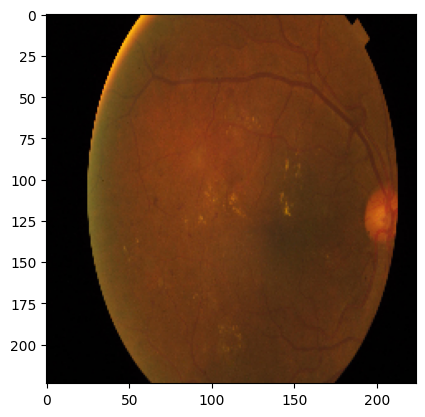

In [115]:
#print max and min pixel values of our image to see if normalized already or not
print(f"Min pixel value: {training_images[0][0].min()}, Max pixel value: {training_images[0][0].max()}")

#printing the length of our dataset
print(len(training_images))
#(3662, 224,224, 3), this represents the number of samples , and the shape of each image with 3 channels RGB

#visualize the first fundus image in the datset, ensure its in RGB
plt.imshow(cv2.cvtColor(training_images[0][0], cv2.COLOR_BGR2RGB))
plt.show()

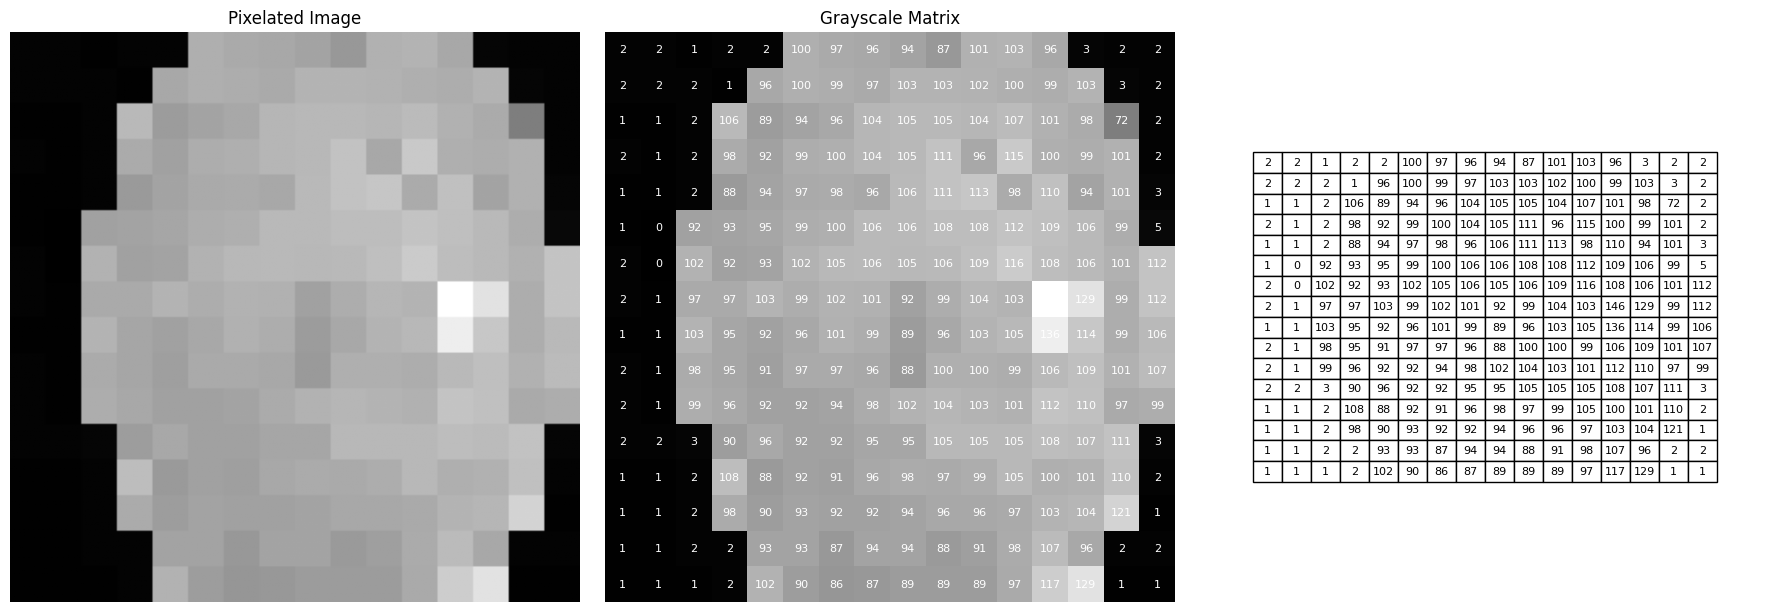

In [116]:
# Display the pixel intensity values of a patient with Proliferative DR (PDF)
PDF_img = training_images[1][0]  # Access the image of the second patient (Proliferative DR)

# Ensure the image is in grayscale
if len(PDF_img.shape) == 3:  # If the image has 3 channels (RGB/BGR)
    PDF_img = cv2.cvtColor(PDF_img, cv2.COLOR_BGR2GRAY)

# Resize the image to make it pixelated (16x16)
pixelated_image = cv2.resize(PDF_img, (16, 16), interpolation=cv2.INTER_NEAREST)

# Resize it back to the original size for visualization purposes
pixelated_resized = cv2.resize(pixelated_image, (PDF_img.shape[1], PDF_img.shape[0]), interpolation=cv2.INTER_NEAREST)

# Prepare the figure
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. Display the pixelated image resized back to the original size
axes[0].imshow(pixelated_resized, cmap='gray')
axes[0].set_title("Pixelated Image")
axes[0].axis('off')

# 2. Display the grayscale pixel values as an image
axes[1].imshow(pixelated_image, cmap='gray')
for i in range(pixelated_image.shape[0]):
    for j in range(pixelated_image.shape[1]):
        value = pixelated_image[i, j]
        # Display the pixel value on the image
        axes[1].text(j, i, f"{value}", color='white', ha='center', va='center', fontsize=8)
axes[1].set_title("Grayscale Matrix")
axes[1].axis('off')

# 3. Display the raw pixel values in a table format
axes[2].axis('tight')
axes[2].axis('off')
table_data = pixelated_image.astype(int)  # Ensure integer values for display
pixel_table = axes[2].table(
    cellText=table_data, loc='center', cellLoc='center', colWidths=[0.05] * 16
)
pixel_table.auto_set_font_size(False)
pixel_table.set_fontsize(8)

# Adjust layout for better visualization

plt.tight_layout()
plt.show()



# The pathology of Diabetic Retinopathy 
- Below is an Image of indicators we can notice in a DR patient

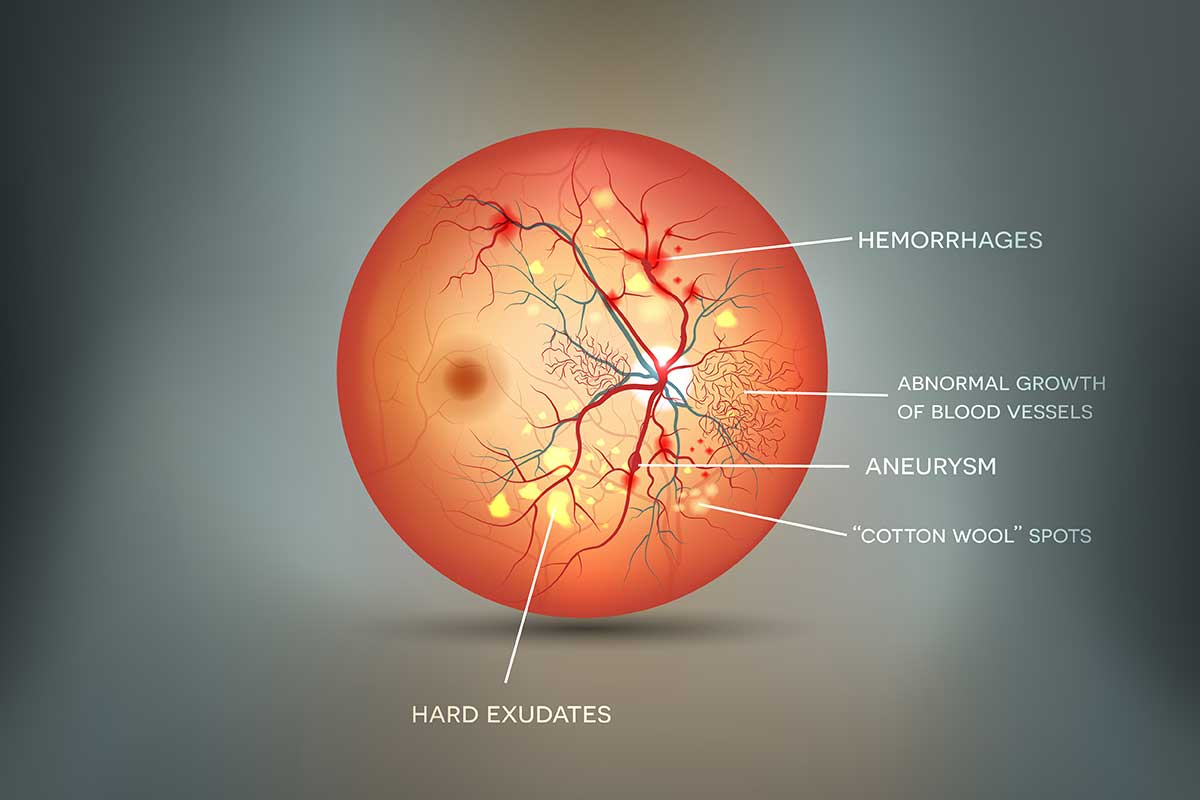

In [117]:
diagram_path = os.getenv("DIAGRAM_IMG")

# Display the image
display(Image(filename=diagram_path, width=600)) 


# Raw Samples of Images before any Preprocessing

Appended image at index 0 for label 2
Appended image at index 1 for label 4
Appended image at index 2 for label 1
Appended image at index 3 for label 0
Appended image at index 4 for label 0
Appended image at index 5 for label 4
Appended image at index 7 for label 2
Appended image at index 9 for label 1
Appended image at index 13 for label 3
Appended image at index 49 for label 3


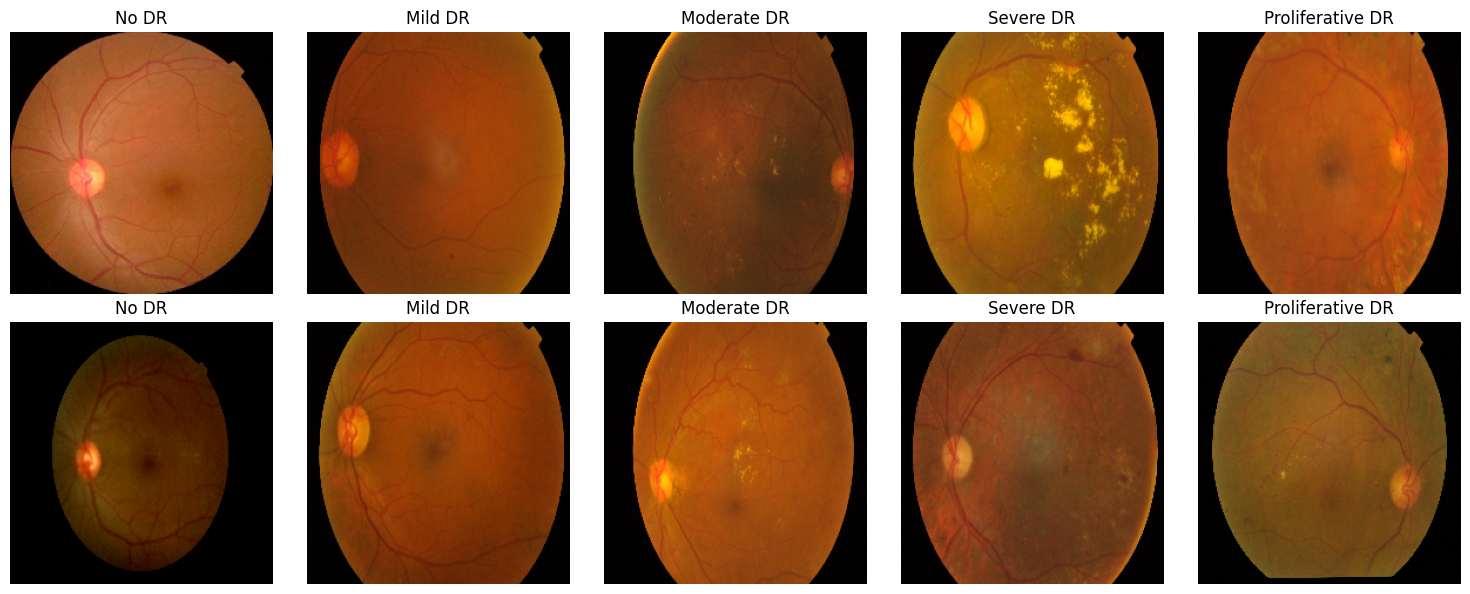

In [118]:
#show some samples with their labels
#iterate through the samples
#if we get 2 samples of a single grading, then stop searching for that label

def fetch_samples(dataset, num_of_classes=5):
    sample_dict = {label: [] for label in range(num_of_classes)}
    
    for idx , data in enumerate(dataset):
         
        X, y  = data
        label = y[0]
        

        #check if we already have the label in our dict
        if label not in sample_dict:
            sample_dict[label] = []
        
        if len(sample_dict[label])<2:
            sample_dict[label].append(X) 
            #confirmation to ensure we plot the exact images for each coressponding label
            print(f"Appended image at index {idx} for label {label}")
        #now if all samples have a list of 2, then exit the iteration
        # meaning {0:[img1,img5] etc}   

        #returns true if (sample) is true for all values in the iterable
        if all(len(sample)==2 for sample in sample_dict.values()):
            break

    return sample_dict    


data = fetch_samples(training_images)





#visualize 2 samples per grading with titles -  10 in total
def visualize_samples(samples):
    # Create a figure with 5 columns (for 5 labels) and 2 rows (for 2 images per label)
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))  # 2 rows, 5 columns

    # Iterate over the dictionary of samples
    for label, images in samples.items():
        for i, img in enumerate(images):
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            # Access the correct subplot using label and row index
            ax = axes[i, label]  # Row `i` and column `label`


            #change the value of lables to their correct severity gradings
            class_name= None

            if label == 0:
                class_name = "No DR"

            elif label == 1: 
                class_name = "Mild DR"    

            elif label == 2:
                class_name = "Moderate DR"  

            elif label == 3:
                class_name = "Severe DR"    

            elif label == 4:
                class_name = "Proliferative DR"      


            # Plot the image
            ax.imshow(img, cmap="gray")  # Use 'gray' or other colormaps as necessary
            ax.set_title(f"{class_name}")  # Set the title to show the class
            ax.axis("off")  # Turn off axes for cleaner visualization

    # Adjust layout
    plt.tight_layout()
    plt.show()


unprocessed_samples = visualize_samples(data)
unprocessed_samples



In [119]:
#number of samples per class
print(count)

{'No DR': 1805, 'Mild DR': 370, 'Moderate DR': 999, 'Severe DR': 193, 'Proliferative DR': 295}


# Class Distributions

A cruical part of data exploration is understanding the distributions of samples within the dataset.

- If the prevelence of the Majority class with respect to the Minority classes is high, then this leads to a biased model.

- A biased model will further affect generalizability as the model is not well trained on other DR gradings

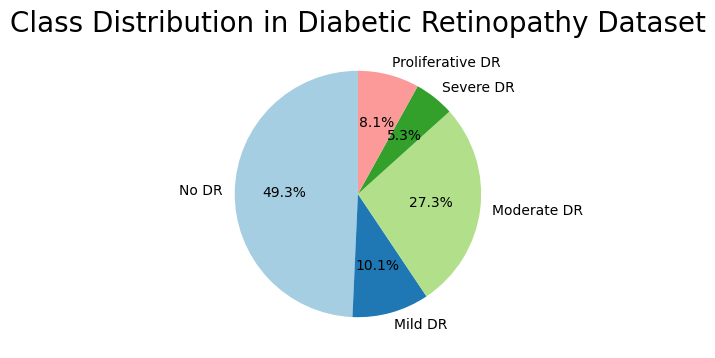

In [120]:
# Pie Chart
plt.figure(figsize=(6, 4))
plt.pie(count.values(), labels=count.keys(), autopct='%1.1f%%', startangle=90, colors=plt.cm.Paired.colors)
plt.title("Class Distribution in Diabetic Retinopathy Dataset", fontsize=20)
plt.show()

<BarContainer object of 5 artists>

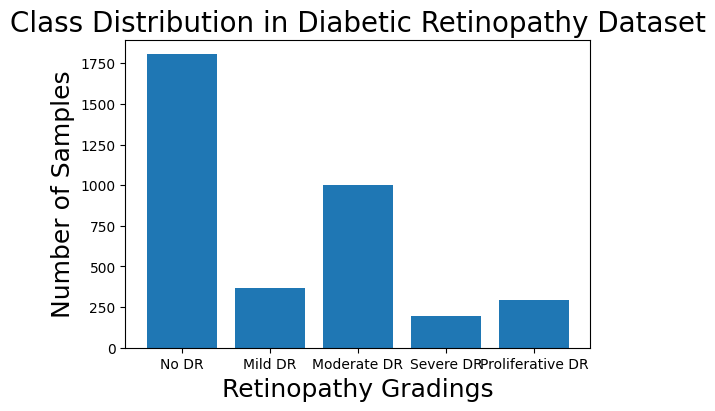

In [121]:
#visualising the class imbalance with a bar chart
plt.figure(figsize=(6, 4))  
plt.xlabel("Retinopathy Gradings", fontsize=18)
plt.ylabel("Number of Samples", fontsize=18)
plt.title("Class Distribution in Diabetic Retinopathy Dataset", fontsize=20)


plt.bar(count.keys(), count.values())
#plt.show()

# Class Imbalance - OverSampling Minority classes with Data Augmentation
- As we can see from the above Severity gradings, No DR has 1805 samples which is exactly 49.3% of the total distribution.
- We can apply a weighted Oversampling technique such that the data points of the minority instances match that of the majority class 



In [122]:
#split the current trainset into 10% val set 10% test set and 80% train set
#we apply augmentations to only the trainset to avoid overfitting.





